# Airline Passengers Forecasting
---

## Dataset
Airline Passengers (1949 - 1960), containing monthly passenger totals.

## Goal
Forecast future airline passenger demand using time series models and analyze seasonal patterns.

## Tools
- Python
- Pandas
- Statsmodels
- Matplotlib

## Overview
This project applies time series analysis techniques, including ARIMA and SARIMA, to model and forecast airline passenger traffic. The goal is to understand trend and seasonality patterns and provide insights for demand planning.

## Step 1 - Load & Inspect Dataset
---
The dataset contains monthly airline passenger counts from 1949 to 1960.
Initial inspection is performed to understand data structure, data types, and check for missing values.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
BASE_DIR = os.path.dirname(os.getcwd())
file_path = os.path.join(BASE_DIR, "data_raw", "AirPassengers.csv")
df = pd.read_csv(file_path)

# Inspect dataset
print("Dataset Info:")
df.info()

print("\nColumns:")
print(df.columns)

print("\nShape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB

Columns:
Index(['Month', '#Passengers'], dtype='object')

Shape:
(144, 2)

First 5 rows:
     Month  #Passengers
0  1949-01          112
1  1949-02          118
2  1949-03          132
3  1949-04          129
4  1949-05          121


## Step 2 - Data Cleaning & Preparation
---
This step prepares the dataset for time series analysis by cleaning column names, validating data quality, and formatting the date column.

In [2]:
# Step 2.1 - Rename column
df.rename(columns={"#Passengers": "Passengers"}, inplace=True)

# Step 2.2 - Check zero or negative values in 'Passengers'
print("Any zero values?", (df['Passengers'] == 0).sum())
print("Any negative values?", (df['Passengers'] < 0).sum())

# Step 2.3 - Convert 'Month' to datetime
df["Month"] = pd.to_datetime(df['Month'])

# Step 2.4 - Set 'Month' as index
df.set_index('Month', inplace=True)
df = df.asfreq('MS')  # Ensure monthly frequency

# -------------------
# Export cleaned CSV for Power BI
data_clean_folder = os.path.join(BASE_DIR, "data_clean")
os.makedirs(data_clean_folder, exist_ok=True)

df_export = df.reset_index().rename(columns={'Month': 'Date'})

data_clean_path = os.path.join(data_clean_folder, 'airline_passengers_cleaned.csv')

df_export.to_csv(data_clean_path, index=False)

Any zero values? 0
Any negative values? 0


## Step 3 - Visualization
---
Initial visualization is performed to observe overall trend and seasonality in airline passenger data.

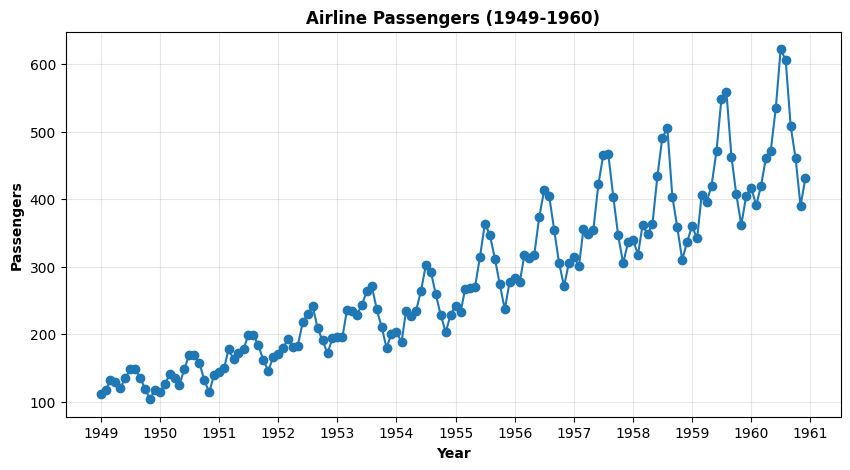

In [3]:
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], marker='o')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Airline Passengers (1949-1960)", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Passengers", fontweight='bold')

plt.grid(True, alpha=0.3)

image_path = os.path.join(BASE_DIR, "assets" , "images", "passenger_trend_1949_1960.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

## Step 4 - Stationarity Check
---
Differencing is applied to remove trend and seasonality, followed by the Augmented Dickey-Fuller (ADF) test to very stationarity.

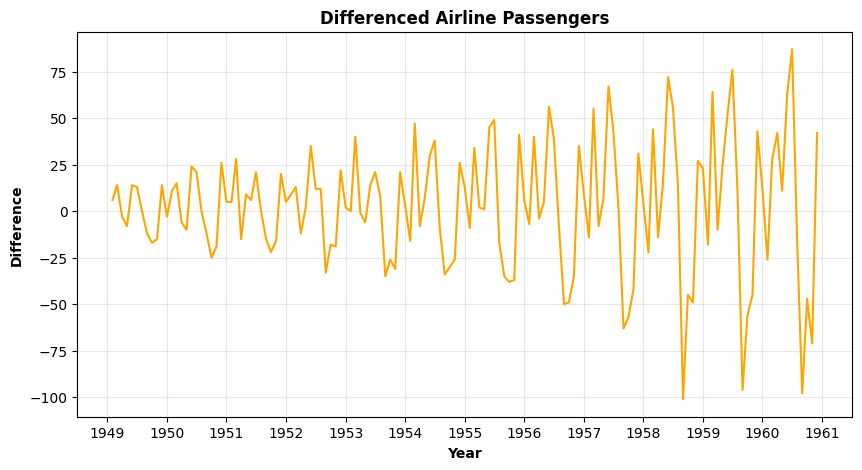

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


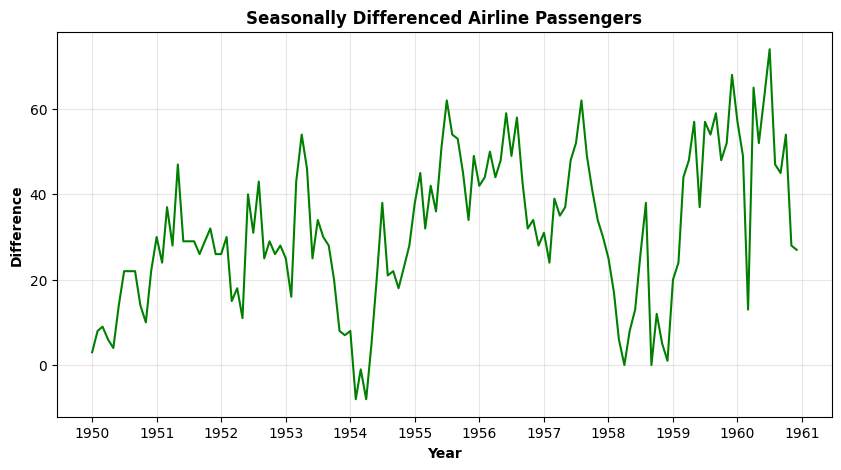

ADF Statistic: -3.383020726492481
p-value: 0.011551493085514954


In [4]:
# Step 4.1 - Apply Differencing
df_diff = df.diff().dropna()

# Step 4.2 - Plot Differenced Data
plt.figure(figsize=(10,5))
plt.plot(df_diff['Passengers'], color='orange')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Differenced Airline Passengers", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Difference", fontweight='bold')

plt.grid(True, alpha=0.3)

image_path = os.path.join(BASE_DIR, "assets" , "images", "differenced_airline_passengers.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

# Step 4.3 - ADF Test

result_diff = adfuller(df_diff['Passengers'])

print("ADF Statistic:", result_diff[0])
print("p-value:", result_diff[1])

# Step 4.4 - Seasonal Differencing
df_seasonal_diff = df.diff(12).dropna()

plt.figure(figsize=(10,5))
plt.plot(df_seasonal_diff['Passengers'], color='green')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.title("Seasonally Differenced Airline Passengers", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Difference", fontweight='bold')

plt.grid(True, alpha=0.3)

image_path = os.path.join(BASE_DIR, "assets" , "images", "seasonally_differenced_airline_passengers.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

result_seasonal = adfuller(df_seasonal_diff['Passengers'])

print("ADF Statistic:", result_seasonal[0])
print("p-value:", result_seasonal[1])

### Stationarity Check

Initial differencing (d=1) was applied to remove  the trend.
However, the Augmented Dickey-Fuller test returned a p-value of 0.054,
indicating the series was still not fully stationary.

Seasonal differencing with a lag of 12 was then applied to remove yearly seasonality

After seasonal differencing:
- ADF Statistic: -3.15
- p-value: 0.022

Since the p-value is below 0.05, the series is now stationary.

This confirms that both trend and seasonality were present in the data.

Therefore:
- d = 1 (trend differencing)
- D = 1 (seasonal differencing)
- s = 12 (monthly seasonality)

## Step 5 - ACF & PACF 
---
ACF and PACF are used to identify potential AR and MA components for both ARIMA and SARIMA modeling

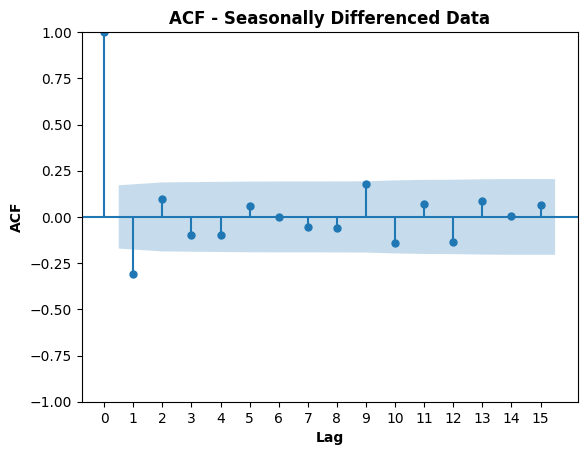

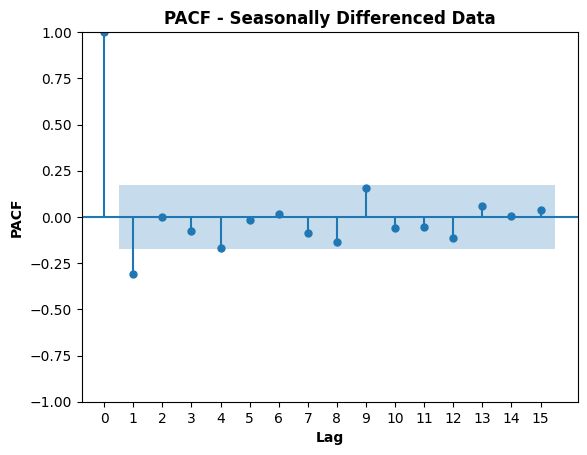

ACF Values:
Lag 0: 1.000
Lag 1: -0.310
Lag 2: 0.095
Lag 3: -0.097
Lag 4: -0.099
Lag 5: 0.061
Lag 6: -0.000
Lag 7: -0.056
Lag 8: -0.061
Lag 9: 0.176
Lag 10: -0.140
Lag 11: 0.070
Lag 12: -0.134
Lag 13: 0.087
Lag 14: 0.002
Lag 15: 0.065

PACF Values:
Lag 0: 1.000
Lag 1: -0.310
Lag 2: -0.001
Lag 3: -0.075
Lag 4: -0.167
Lag 5: -0.015
Lag 6: 0.018
Lag 7: -0.088
Lag 8: -0.134
Lag 9: 0.156
Lag 10: -0.059
Lag 11: -0.052
Lag 12: -0.115
Lag 13: 0.060
Lag 14: 0.004
Lag 15: 0.037


In [5]:
df_final = df.diff().diff(12).dropna()

# Step 5.1 - ACF plot
plot_acf(df_final['Passengers'], lags=15)
plt.title("ACF - Seasonally Differenced Data", fontweight='bold')
plt.xlabel("Lag", fontweight='bold')
plt.ylabel("ACF", fontweight='bold')
plt.xticks(range(0,16))

image_path = os.path.join(BASE_DIR, "assets" , "images", "acf_seasonally_differenced.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

# Step 5.2 - PACF plot
plot_pacf(df_final['Passengers'], lags=15, method='ywm')
plt.title("PACF - Seasonally Differenced Data", fontweight='bold')
plt.xlabel("Lag", fontweight='bold')
plt.ylabel("PACF", fontweight='bold')
plt.xticks(range(0,16))

image_path = os.path.join(BASE_DIR, "assets" , "images", "pacf_seasonally_differenced.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

# Step 5.3 - ACF & PACF Values
max_lags = 15
acf_vals = acf(df_final['Passengers'], nlags=max_lags)
pacf_vals = pacf(df_final['Passengers'], nlags=max_lags, method='ywm')

print("ACF Values:")
for i, v in enumerate(acf_vals):
    print(f"Lag {i}: {v:.3f}")

print("\nPACF Values:")
for i, v in enumerate(pacf_vals):
    print(f"Lag {i}: {v:.3f}")


### ACF & PACF Insights

ACF and PACF were analyzed on the fully differenced series (d=1, D=1).

The ACF shows a gradual decay with no clear cutoff, suggesting no strong MA component (q =0).

The PACF shows a significant spike at lag 1 followed by a sharp drop, indicating an AR(1) component.

Seasonal effects are no longer prominent after seasonal differencing.

Therefore, the final selected model is:
SARIMA(1,1,0)(1,1,0,12)

## Step 6A - Build ARIMA (Baseline Model)
---
ARIMA is used as a baseline forecasting model before comparing it with SARIMA, which can capture seasonal patterns. 

                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -698.926
Date:                Thu, 28 May 2026   AIC                           1401.852
Time:                        17:16:35   BIC                           1407.778
Sample:                    01-01-1949   HQIC                          1404.260
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3066      0.080      3.849      0.000       0.150       0.463
sigma2      1029.2429    103.738      9.922      0.000     825.920    1232.566
Ljung-Box (L1) (Q):                   0.66   Jarque-

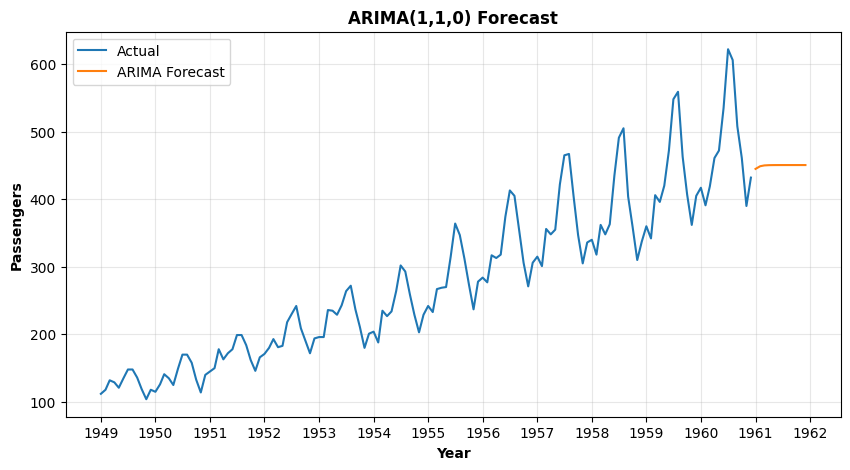

In [6]:
# ARIMA (1,1,0)

# Step 6A.1 - Build the model

# Build ARIMA model
model_arima = ARIMA(df['Passengers'], order=(1,1,0))

model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())
print("ARIMA AIC:", model_arima_fit.aic)

# Step 6A.2 - Forecast (next 12 months)
forecast_arima = model_arima_fit.forecast(steps=12)

print(forecast_arima)

# Step 6A.3 - Plot forecast

plt.figure(figsize=(10,5))

# Actual data
plt.plot(df['Passengers'], label="Actual")

# Forecast
forecast_index = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),  # Start from the month after the last actual point
    periods=12, 
    freq='MS'  # Monthly start frequency
)

plt.plot(forecast_index, forecast_arima, label="ARIMA Forecast")

plt.title("ARIMA(1,1,0) Forecast", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Passengers", fontweight='bold')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, alpha=0.3)
plt.legend()

image_path = os.path.join(BASE_DIR, "assets" , "images", "arima_110_forecast.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

### ARIMA Baseline Model Insights

An ARIMA(1,1,0) model was trained as a baseline forecasting model.

The model achieved an AIC score of 1401.85.

The forecast captures the general upward trend in passenger demand, but seasonal patterns are not clearly represented.

Forecast values gradually become stable around 450 passengers, indicating that the model struggles to capture repeating yearly fluctuations.

This limitation is expected because ARIMA does not explicitly model seasonality.

Therefore, SARIMA will be explored next to better capture both trend and seasonal behavior in the data.

## Step 6B - Build SARIMA
---
SARIMA extends ARIMA by incorporating seasonal components, making it more suitable for forecasting data with repeating yearly structure.

                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -507.196
Date:                            Thu, 28 May 2026   AIC                           1020.393
Time:                                    17:16:36   BIC                           1029.019
Sample:                                01-01-1949   HQIC                          1023.898
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2965      0.082     -3.601      0.000      -0.458      -0.135
ar.S.L12      -0.1397      0.091   

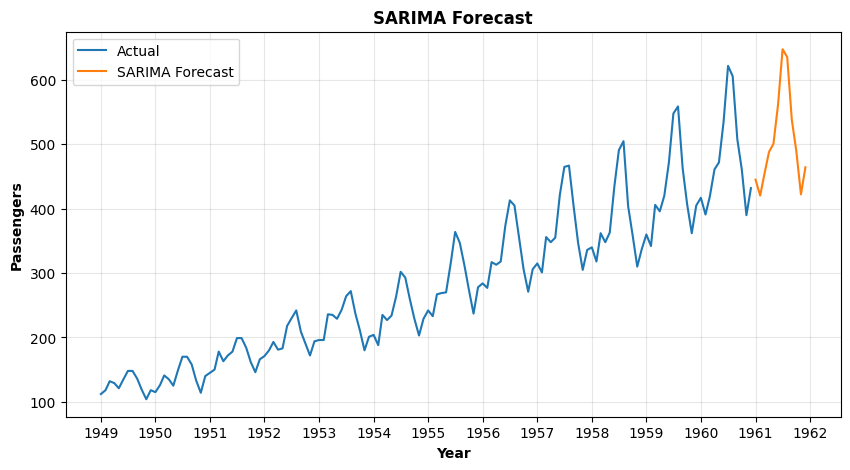

In [7]:
# SARIMA model (1,1,0)(1,1,0,12)

# Step6B.1 - Build the model

# Build SARIMA model
model_sarima = SARIMAX(
    df['Passengers'],
    order=(1,1,0),
    seasonal_order=(1,1,0,12)
)

model_sarima_fit = model_sarima.fit()

print(model_sarima_fit.summary())
print("SARIMA AIC:", model_sarima_fit.aic)

# Step 6B.2 - Forecast (next 12 months)
forecast_sarima = model_sarima_fit.forecast(steps=12)

print(forecast_sarima)

# Step 6B.3 - Plot forecast
plt.figure(figsize=(10,5))

# Actual
plt.plot(df['Passengers'], label="Actual")

# Forecast
forecast_index = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),  # Start from the month after the last actual point,
    periods=12,
    freq='MS'  # Monthly start frequency
)

plt.plot(forecast_index, forecast_sarima, label="SARIMA Forecast")

plt.title("SARIMA Forecast", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Passengers", fontweight='bold')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, alpha=0.3)
plt.legend()

image_path = os.path.join(BASE_DIR, "assets" , "images", "sarima_11012_forecast.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

# Step 6B.4 - Export forecast for Power BI

forecast_df = pd.DataFrame({
    "Date": forecast_index,
    "Forecast": forecast_sarima.values
})

forecast_df = forecast_df.reset_index(drop=True)

forecast_df.to_csv(
    os.path.join(BASE_DIR, "data_clean", "sarima_forecast.csv"),
    index=False
)

### Model Comparison: ARIMA vs SARIMA

The ARIMA(1,1,0) model was first used as a baseline. While it captured short-term dependencies, it failed to model the strong seasonal pattern, producing overly smooth forecasts.

A SARIMA(1,1,0)(1,1,0,12) model was then applied to incorporate seasonality.

Model comparison results:
- AIC improved significantly from 1401.85 to 1020.39
- Forecasts now reflect realistic seasonal patterns with repeating peaks and troughs

This demonstrates that SARIMA is more suitable for time series data with strong seasonal behavior.

## Step 7 - Build alternative models
---
Multiple SARIMA models were evaluated using AIC to identify the best-performing configuration

In [8]:
# Step 7.1 - Build alternative models

# Model 1 (current best)
model_1 = SARIMAX(df['Passengers'], order=(1,1,0), seasonal_order=(1,1,0,12)).fit()

# Model 2 (add MA term)
model_2 = SARIMAX(df['Passengers'], order=(1,1,1), seasonal_order=(1,1,0,12)).fit()

# Model 3 (stronger AR)
model_3 = SARIMAX(df['Passengers'], order=(2,1,0), seasonal_order=(1,1,0,12)).fit()

# Step 7.2 - Compare AIC
print("Model 1 AIC:", model_1.aic)
print("Model 2 AIC:", model_2.aic)
print("Model 3 AIC:", model_3.aic)

Model 1 AIC: 1020.3929484516353
Model 2 AIC: 1022.3557767678984
Model 3 AIC: 1022.3728028733576


### Final Model Selection

Multiple SARIMA models were evaluated using AIC to determine the best-performing configuration

- SARIMA(1,1,0)(1,1,0,12): 1020.39
- SARIMA(1,1,1)(1,1,0,12): 1022.36
- SARIMA(2,1,0)(1,1,0,12): 1022.37

**Final Selected Model: SARIMA(1,1,0)(1,1,0,12)**

The SARIMA(1,1,0)(1,1,0,12) model achieved the lowest AIC, indicating the best balance between model fit and complexity.

This confirms that the initial parameter selection based on ACF and PACF analysis was appropriate, and that adding additional AR or MA terms did not improve performance.

## Step 8 - Evaluation
---
Using the best-performing SARIMA model selected in Step 7 based on the lowest AIC

Train shape: (132, 1)
Test shape: (12, 1)
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  132
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 12)   Log Likelihood                -447.411
Date:                            Thu, 28 May 2026   AIC                            900.823
Time:                                    17:16:37   BIC                            909.160
Sample:                                01-01-1949   HQIC                           904.208
                                     - 12-01-1959                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2317      0.091     -2.540      0.011      -0.411      

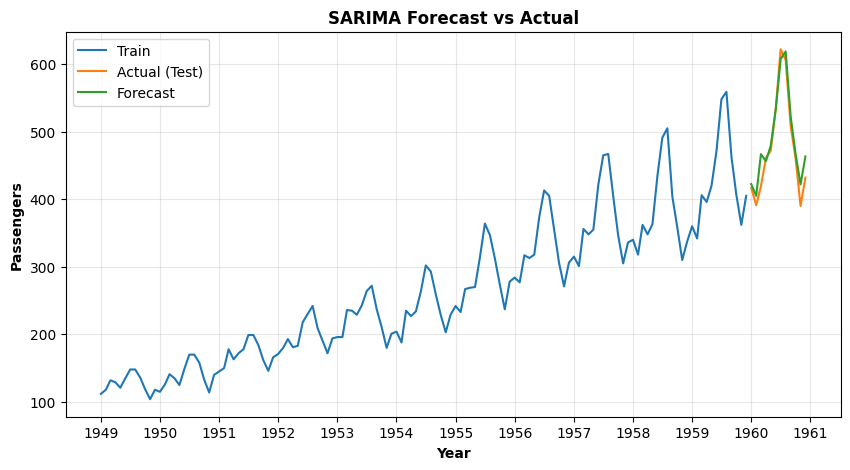

Min Passengers per month: 104
Max Passengers per month: 622

RMSE: 20.81 (3.35%)
MAE: 15.99 (2.57%)


In [9]:
# Step 8.1 - Split the data into training and testing sets

# last 12 months = test set
# rest = training

# Train-test split
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Step 8.2 - Train model on TRAIN only

eval_model = SARIMAX(
    train['Passengers'],
    order=(1,1,0),
    seasonal_order=(1,1,0,12)
)

eval_model_fit = eval_model.fit()
print(eval_model_fit.summary())

# Step 8.3 - Predict TEST period
forecast = eval_model_fit.forecast(steps=12)

# Step 8.4 - Compare visually

plt.figure(figsize=(10,5))

plt.plot(train['Passengers'], label ="Train")
plt.plot(test['Passengers'], label="Actual (Test)")
plt.plot(test.index, forecast, label="Forecast")

plt.legend()
plt.grid(True, alpha=0.3)
plt.title("SARIMA Forecast vs Actual", fontweight='bold')
plt.xlabel("Year", fontweight='bold')
plt.ylabel("Passengers", fontweight='bold')

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

image_path = os.path.join(BASE_DIR, "assets" , "images", "sarima_forecast_actual.png")
plt.savefig(image_path, dpi=300, bbox_inches='tight')

plt.show()

# Step 8.5 - RMSE & MAE

print("Min Passengers per month:", df['Passengers'].min())
print("Max Passengers per month:", df['Passengers'].max())

# RMSE 
rmse = np.sqrt(mean_squared_error(test['Passengers'], forecast))

# MAE
mae = mean_absolute_error(test['Passengers'], forecast)

rmse_pct = (rmse / df['Passengers'].max()) * 100
mae_pct = (mae / df['Passengers'].max()) * 100

print(f"\nRMSE: {rmse:.2f} ({rmse_pct:.2f}%)")
print(f"MAE: {mae:.2f} ({mae_pct:.2f}%)")

### Model Evaluation

The dataset was split into training (first 132 months) and testing (last 12 months), where the test set was treated as unseen data.

The SARIMA forecast closely follows the actual test data, successfully capturing seasonal peaks and troughs.

This indicates that the model generalizes well and is capable of producing reliable future forecasts.

The model achieved the following performance metrics:
- RMSE: 20.81 (3.35%)
- MAE: 15.99 (2.57%)

Given that passenger values range between 104 - 622, these error values are relatively low.

Overall, the model demonstrates strong predictive performance and effectively captures both trend and seasonality in the dataset.

## Step 9 - Final Conclusion
---

### Conclusion & Insights

The SARIMA model successfully captures both trend and yearly seasonality in airline passenger demand.

This suggests that passenger traffic follows a predictable seasonal pattern, with consistent yearly fluctuations.

### Business Implications

The forecast can help airlines and aviation stakeholders:

- Plan capacity during peak travel seasons
- Optimize staffing and resource allocation
- Improve demand forecasting for revenue planning
- Prepare for seasonal fluctuations in advance

### Limitations

- The dataset is small (144 monthly)
- External factors such as economic changes, pandemics, fuel prices, global crisis are not included
- The model assumes that historical patterns will remain stable over time.
- Only univariate forecasting was used (no external variables)

### Next Steps

To improve the model:

- Include external variables to perform ARIMAX, such as GDP, festive seasons, promotions, fuel prices or travel demand factors
- Try other forecasting like Prophet or LSTM (Long Short-Term Memory)
- Perform hyperparameter tuning for SARIMA
- Expand dataset with more recent airline data

Overall, the SARIMA model provides a reliable baseline forecasting approach for airline passenger demand and demonstrates the importance of incorporating seasonality in time series analysis.